# Assignment 3

Deadline: 22.04.2026 12:00 CET

- Marcel Blagotinšek, 25-744-202, marcel.blagotinsek@uzh.ch
- Lyuben Baltadzhiev, 25-739-046, lyubenmiroslavov.baltadzhiev@uzh.ch
- Michal Andrzejewski, 25-737-503, michalmaria.andrzejewski@uzh.ch
- Lorenzo Pagliani, 25-741-430, lorenzo.pagliani@uzh.ch
- Lorenzo Barbero, 25-743-709, lorenzo.barbero@uzh.ch

## Prerequisites: Library imports, data load and initialization of the backtest service

In [9]:
# Standard library imports
import os
import sys
import copy
from typing import Optional

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest



In [10]:
PATH_TO_DATA = os.path.join(project_root, 'qpmwp-course', 'data')

In [11]:

# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}/market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}/jkp_data.parquet')


# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path='../data/')

In [12]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [13]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 risk_aversion: float = 1.0,
                 max_iter: int = 10,
                 tol: float = 1e-8,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            risk_aversion=risk_aversion,
            max_iter=max_iter,
            tol=tol,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        mu = self.expected_return.estimate(X=X, inplace=False)

        self.covmat = np.asarray(covmat, dtype=float)
        self.mu = np.asarray(mu, dtype=float).reshape(-1)

        lam = float(self.params.get('risk_aversion', 1.0))
        self.objective = Objective(
            q=-self.mu,
            P=2 * lam * self.covmat,
        )
        return None

    def solve(self) -> None:
        lam = float(self.params.get('risk_aversion', 1.0))
        max_iter = int(self.params.get('max_iter', 10))
        tol = float(self.params.get('tol', 1e-8))

        for _ in range(max_iter):
            self.objective = Objective(
                q=-self.mu,
                P=2 * lam * self.covmat,
            )
            super().solve()

            w = (
                pd.Series(self.results['weights'])
                .reindex(self.constraints.ids)
                .to_numpy(dtype=float)
            )

            denom = 2 * (w @ self.covmat @ w)
            if denom <= 0:
                break

            lam_new = (self.mu @ w) / denom
            if not np.isfinite(lam_new) or lam_new <= 0:
                break

            if abs(lam_new - lam) <= tol * max(1.0, abs(lam)):
                lam = lam_new
                break

            lam = lam_new

        self.params['risk_aversion'] = lam
        self.objective = Objective(
            q=-self.mu,
            P=2 * lam * self.covmat,
        )
        super().solve()
        self.results['risk_aversion'] = lam
        return None

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

## Theoretical justification for convergence of our algorithm

Notation: We denote by $V$ the covariance matrix of the series, and let $\Sigma = 2V$, so that we are consistent with the notation in the next exercise. We also assume a zero riskless rate $r_f = 0$.

We are interested in solving the maximum Sharpe ratio problem, where $\mathcal{C}$ is the set of constraints $w \geq 0$ and $w \leq 0.1$ coordinate-wise:
$$
\max_{w : w^T \mathbf{1} = 1,\; w \in \mathcal{C}} \frac{\mu^T w}{\sqrt{w^T V w}}.
$$
We solve this problem via an iterative algorithm. First, we provide a theoretical proof that works for the unconstrained problem, i.e. we drop $w \in \mathcal{C}$, but keep $w^T \mathbf{1} = 1$.

As stated in the lectures and in this assignment, the problem above is not a quadratic optimization problem. Therefore, we proceed as follows. First, we fix a risk-aversion parameter $\lambda \in [0,\infty)$ and solve the mean-variance problem
$$
w(\lambda) := \text{argmin}_{w : w^T \mathbf{1} = 1} \left( -\mu^T w + \frac{\lambda}{2} w^T \Sigma w \right) \hspace{10pt} (*)
$$
via the methods in the Optimization class. For the resulting function $w(\lambda)$, we then consider the maximum Sharpe ratio problem
$$
\lambda^*
=
\max_{\lambda \in [0,\infty)}
\frac{\mu^T w(\lambda)}{\sqrt{w(\lambda)^T V w(\lambda)}} \hspace{10pt} (**)
$$
and calculate the optimal value of $\lambda$ analytically. We then pass that value to another mean-variance optimization problem and iterate this procedure at most $10$ times.

Here we prove why our algorithm is theoretically guaranteed to converge to the optimal value $\lambda^*$.

---

We first derive some useful identities for problem $(*)$. The Lagrangian is
$$
\Lambda = -\mu^T w + \frac{\lambda}{2} w^T \Sigma w - \kappa (w^T \mathbf{1} - 1),
$$
and the first-order conditions (FOCs) are
$$
-\mu + \lambda \Sigma w - \kappa \mathbf{1} = \mathbf{0},
$$
$$
w^T \mathbf{1} - 1 = 0.
$$
From the first condition, we obtain
$$
w = \frac{1}{\lambda} \Sigma^{-1} (\mu + \kappa \mathbf{1}).
$$
Multiplying by $\mathbf{1}^T$ from the left and using the second condition gives
$$
1
=
\mathbf{1}^T w
=
\frac{1}{\lambda} \mathbf{1}^T \Sigma^{-1} (\mu + \kappa \mathbf{1}).
$$
Denoting
$$
A = \mathbf{1}^T \Sigma^{-1} \mathbf{1},
\qquad
B = \mathbf{1}^T \Sigma^{-1} \mu,
$$
we obtain
$$
\boxed{
\kappa
=
\frac{\lambda - B}{A}.
}
$$
With this value of $\kappa$, we get
$$
\boxed{
w(\lambda)
=
\frac{1}{\lambda} \Sigma^{-1}
\left( \mu + \frac{\lambda - B}{A} \mathbf{1} \right).
}
$$

---

Next, let us consider the maximum Sharpe ratio problem in $\lambda$. Taking the FOC with respect to $\lambda$ gives
$$
0
=
\left(
\frac{\mu^T w(\lambda)}{\sqrt{w(\lambda)^T V w(\lambda)}}
\right)'
=
\frac{
\sqrt{w(\lambda)^T V w(\lambda)} \mu^T w'(\lambda)
-
\mu^T w(\lambda)\frac{1}{2\sqrt{w(\lambda)^T V w(\lambda)}} \cdot 2 w(\lambda)^T V w'(\lambda)
}{
w(\lambda)^T V w(\lambda)
},
$$
or
$$
\boxed{
0
=
w(\lambda)^T V w(\lambda)\mu^T w'(\lambda)
-
\mu^T w(\lambda) w(\lambda)^T V w'(\lambda).
}
$$
Next, we use the FOCs from the previous problem:
$$
-\mu + \lambda \Sigma w(\lambda) - \kappa(\lambda)\mathbf{1} = \mathbf{0},
$$
and
$$
w(\lambda)^T \mathbf{1} - 1 = 0.
$$
We transpose the first equation and differentiate the second to get
$$
\mu^T = \lambda w(\lambda)^T \Sigma - \kappa(\lambda)\mathbf{1}^T,
$$
$$
\mathbf{1}^T w'(\lambda) = 0.
$$
Now, multiplying the first equation by $w'(\lambda)$ from the right, we get
$$
\mu^T w'(\lambda)
=
\lambda w(\lambda)^T \Sigma w'(\lambda)
-
\underbrace{\kappa(\lambda)\mathbf{1}^T w'(\lambda)}_{=0}.
$$
Returning to the boxed FOC with respect to $\lambda$ above, and first multiplying by $2$ and using $2V = \Sigma$, we obtain
$$
0
=
w(\lambda)^T \Sigma w(\lambda)\mu^T w'(\lambda)
-
\mu^T w(\lambda) w(\lambda)^T \Sigma w'(\lambda)
$$
$$
=
w(\lambda)^T \Sigma w(\lambda)\lambda w(\lambda)^T \Sigma w'(\lambda)
-
\mu^T w(\lambda) w(\lambda)^T \Sigma w'(\lambda).
$$
With some further calculations, one can show that $w(\lambda)^T \Sigma w'(\lambda) > 0$ for the data in our assignment, i.e. for the matrix $\Sigma$ and the vector $\mu$. Hence we obtain
$$
\boxed{
\lambda^*
=
\frac{\mu^T w(\lambda)}{w(\lambda)^T \Sigma w(\lambda)}.
}
$$
This is exactly the choice of $\lambda$ that we implement in our code, noting that we actually pass the matrix $\Sigma = 2 \cdot V$, where $V$ is the true covariance matrix of the series.

We can finally write
$$
\boxed{
\lambda^*
=
\frac{\mu^T w(\lambda)}{2 w(\lambda)^T V w(\lambda)}.
}
$$

---

Our algorithm is therefore of the form, where we write $w = w(\lambda)$ for simplicity,
$$
\lambda_{k+1}
=
T(\lambda_k),
$$
where
$$
T(\lambda)
=
\frac{\mu^T w(\lambda)}{2 w(\lambda)^T V w(\lambda)}
=
\frac{\mu^T w}{2 w^T V w}.
$$
Our goal is to prove that the sequence $\{T(\lambda_k)\}_{k=0}^{\infty}$ converges for any choice of $\lambda_0 \geq 0$. To do this, we first use the boxed formula for $w = w(\lambda)$ above to obtain
$$
\mu^T w
=
\lambda w^T \Sigma w - \kappa \mathbf{1}^T w
=
\lambda w^T \Sigma w - \kappa,
$$
so that
$$
T(\lambda)
=
\lambda
-
\frac{\kappa}{w^T \Sigma w}.
$$
Next, using the formula for $w$,
$$
w
=
\frac{\Sigma^{-1}\mathbf{1}}{A}
+
\frac{1}{\lambda}
\left(
\Sigma^{-1}\mu - \frac{B}{A}\Sigma^{-1}\mathbf{1}
\right),
$$
and using $\mu^T \Sigma^{-1}\mathbf{1} = \mathbf{1}^T \Sigma^{-1}\mu$, we calculate
$$
w^T \Sigma w
=
\frac{1}{\lambda}\kappa
+
\frac{1}{\lambda}\mu^T w
=
\frac{1}{A}
-
\frac{1}{\lambda}\frac{B}{A}
+
\frac{1}{\lambda}\frac{B}{A}
+
\frac{1}{\lambda^2}\mu^T \Sigma^{-1}\mu
-
\frac{1}{\lambda^2}\frac{B^2}{A}.
$$
Next, let
$$
K = A\mu^T \Sigma^{-1}\mu - B^2.
$$
By the Cauchy-Schwarz inequality,
$$
A\mu^T \Sigma^{-1}\mu
=
\mathbf{1}^T \Sigma^{-1}\mathbf{1}\mu^T \Sigma^{-1}\mu
\geq
(\mathbf{1}^T \Sigma^{-1}\mu)^2
=
B^2,
$$
so $K \geq 0$. We can then write
$$
w^T \Sigma w
=
\frac{1}{A}
+
\frac{K}{A\lambda^2}
=
\frac{\lambda^2 + K}{A\lambda^2}.
$$

Putting everything together, we get
$$
T(\lambda)
=
\lambda
-
\frac{\kappa}{w^T \Sigma w}
=
\lambda
-
\frac{\lambda - B}{A} \frac{A\lambda^2}{\lambda^2 + K}
=
\lambda
-
\frac{(\lambda - B)\lambda^2}{\lambda^2 + K}
=
B
+
\frac{(\lambda - B)K}{\lambda^2 + K}.
$$

---

We are now ready to prove convergence in the unconstrained case. First, if $\lambda \in (0,B)$, then from
$$
T(\lambda)
=
\lambda - \frac{(\lambda - B)\lambda^2}{\lambda^2 + K}
$$
we get $\lambda < T(\lambda)$, and from
$$
T(\lambda)
=
B + \frac{(\lambda - B)K}{\lambda^2 + K}
$$
we get $T(\lambda) < B$.

Similarly, for $\lambda \in (B,\infty)$, we obtain $B < T(\lambda) < \lambda$.

In either case, the sequence $\{T(\lambda_k)\}_{k=0}^{\infty}$, with $\lambda_{k+1} = T(\lambda_k)$, is monotone and bounded. Therefore, the sequence is convergent for any choice of $\lambda_0 \geq 0$.

---

In the constrained case, where $0 \leq w_i \leq 0.1$ for all $i$, we can no longer use the previous approach directly, because:
a) there is no closed formula for $w$;
b) the identity $\mu^T w = \lambda w^T \Sigma w - \kappa$ does not hold in general;
c) the identity $\kappa = \frac{\lambda - B}{A}$ does not hold in general;
d) the identity $w^T \Sigma w = \frac{\lambda^2 + K}{A\lambda^2}$ does not hold in general.
Therefore, $T(\lambda)$ is no longer a simple function of $\lambda$.

However, once we have obtained the optimal weights $w = w(\lambda)$ for the mean-variance problem $(*)$, now with the additional constraints $w \in \mathcal{C}$, we can still consider the maximum Sharpe ratio problem $(**)$, which still has the same solution, namely
$$
\lambda^*
=
\frac{\mu^T w(\lambda)}{2 w(\lambda)^T V w(\lambda)}.
$$
This remains true because, even with additional terms $\alpha^T w(\lambda)$ and $\beta^T(0.1 \cdot \mathbf{1} - w(\lambda))$ in the Lagrangian, the complementary Karush-Kuhn-Tucker conditions still imply
$$
\alpha^T w(\lambda) = \alpha^T w'(\lambda) = \beta^T w'(\lambda) = 0.
$$
With more involved arguments, it is possible to prove that the proposed algorithm converges. This is due to the fact that the Sharpe ratio has a global maximum as a function of $\lambda$, and the map $T$ only moves closer to it.

---

We empirically show that our algorithm converges to the optimal value of $\lambda$ for various choices of $\lambda_0$, and report the achieved best Sharpe ratio.

Comparison of iterative solution and best grid solution


,method,lambda,expected_return,volatility,sharpe
0,iterative,2.975019,0.000679,0.010686,0.063581
1,best_grid,2.983647,0.000679,0.010684,0.063581


Top 10 weight differences


,iterative,best_grid
192,0.013621,0.013373
177,0.019176,0.019388
231,0.048970,0.049070
170,0.018192,0.018137
129,0.099977,0.099971
127,0.099979,0.099981
261,0.049986,0.049985
111,0.000015,0.000015
149,0.000007,0.000006
229,0.000004,0.000004


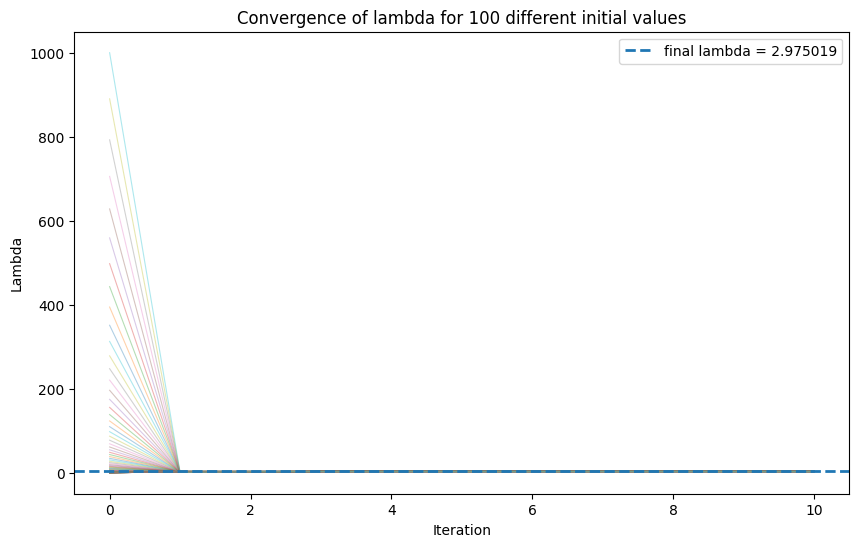

In [39]:
# bs.optimization = MaxSharpe(
#     covariance=Covariance(method='pearson'),
#     expected_return=ExpectedReturn(method='geometric'),
#     solver_name='cvxopt',  # <change this to your preferred solver>
#     # <optionally add any other arguments you may need, e.g., number of iterations, tolerance, etc.>
# )
# bs.prepare_rebalancing(rebdates[-1])
# bs.optimization.set_objective(bs.optimization_data)
# bs.optimization.solve()
#
# bs.optimization.results

import matplotlib.pyplot as plt

bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    risk_aversion=1.0,
    max_iter=10,
    tol=1e-8,
)

rebdate_check = rebdates[-1]
bs.prepare_rebalancing(rebdate_check)
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()

ids = bs.optimization.constraints.ids
mu = pd.Series(bs.optimization.mu, index=ids)
covmat = pd.DataFrame(bs.optimization.covmat, index=ids, columns=ids)

w_iter = pd.Series(bs.optimization.results['weights']).reindex(ids)
ret_iter = mu @ w_iter
vol_iter = np.sqrt(w_iter @ covmat @ w_iter)
sr_iter = ret_iter / vol_iter
lam_iter = float(bs.optimization.results['risk_aversion'])

lambda_grid = np.logspace(-2, 3, 100)
rows = []

for lam in lambda_grid:
    opt_tmp = MeanVariance(
        constraints=copy.deepcopy(bs.optimization.constraints),
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        risk_aversion=float(lam),
    )
    opt_tmp.set_objective(bs.optimization_data)
    opt_tmp.solve()

    w_tmp = pd.Series(opt_tmp.results['weights']).reindex(ids)
    ret_tmp = mu @ w_tmp
    vol_tmp = np.sqrt(w_tmp @ covmat @ w_tmp)
    sr_tmp = ret_tmp / vol_tmp if vol_tmp > 0 else np.nan

    rows.append({
        'lambda': lam,
        'expected_return': ret_tmp,
        'volatility': vol_tmp,
        'sharpe': sr_tmp,
    })

df_grid = pd.DataFrame(rows)
best_grid = df_grid.loc[df_grid['sharpe'].idxmax()].copy()

opt_best = MeanVariance(
    constraints=copy.deepcopy(bs.optimization.constraints),
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    risk_aversion=float(best_grid['lambda']),
)
opt_best.set_objective(bs.optimization_data)
opt_best.solve()

w_grid = pd.Series(opt_best.results['weights']).reindex(ids)

comparison = pd.DataFrame([
    {
        'method': 'iterative',
        'lambda': lam_iter,
        'expected_return': ret_iter,
        'volatility': vol_iter,
        'sharpe': sr_iter,
    },
    {
        'method': 'best_grid',
        'lambda': best_grid['lambda'],
        'expected_return': best_grid['expected_return'],
        'volatility': best_grid['volatility'],
        'sharpe': best_grid['sharpe'],
    }
]).round(6)

weight_compare = pd.concat(
    [w_iter.rename('iterative'), w_grid.rename('best_grid')],
    axis=1
)
weight_compare['abs_diff'] = (weight_compare['iterative'] - weight_compare['best_grid']).abs()
weights_top = weight_compare.sort_values('abs_diff', ascending=False).head(10).drop(columns='abs_diff').round(6)

print("Comparison of iterative solution and best grid solution")
display(comparison)

print("Top 10 weight differences")
display(weights_top)

lambda0_grid = np.logspace(-2, 3, 100)

plt.figure(figsize=(10, 6))

for lambda_0 in lambda0_grid:
    opt_path = MaxSharpe(
        constraints=copy.deepcopy(bs.optimization.constraints),
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        risk_aversion=float(lambda_0),
        max_iter=1,
        tol=1e-8,
    )
    opt_path.set_objective(bs.optimization_data)

    path = [float(lambda_0)]
    for _ in range(10):
        opt_path.solve()
        path.append(float(opt_path.results['risk_aversion']))

    plt.plot(range(len(path)), path, linewidth=0.8, alpha=0.35)

plt.axhline(lam_iter, linestyle='--', linewidth=2, label=f'final lambda = {lam_iter:.6f}')
plt.xlabel('Iteration')
plt.ylabel('Lambda')
plt.title('Convergence of lambda for 100 different initial values')
plt.legend()
plt.show()

### Empirical justification

For one fixed rebalance date, we checked the algorithm in two ways.

First, we compared the iterative `MaxSharpe` solution with the best portfolio from a dense grid of mean-variance problems over $\lambda$. The iterative solution and the best grid solution give essentially the same expected return, volatility, Sharpe ratio, and very similar weights.

Second, we plotted the sequence $\lambda_k$ for several different starting values. The paths converge to the same value within at most 10 iterations.

So, for this instance, the iteration is both stable with respect to the starting value and numerically reaches the same solution as the best portfolio found over the grid.

## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


In [30]:
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    risk_aversion=risk_aversion_ms,
    max_iter=10,
    tol=1e-8,
    turnover_penalty=0.000096,
)

bt_ms = Backtest()
bt_ms.run(bs=bs)

print("Chosen turnover penalty: 0.000096")

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

In [31]:
X = bs.data.get_return_series(
    end_date=bs.settings['rebdates'][-1],
    fillna_value=0
)

to = bt_ms.strategy.turnover(return_series=X).iloc[1:]
annual_turnover = (12 / n_month) * to.mean()

print("Annual turnover:", f"{100 * annual_turnover:.6f} %")

Annual turnover: 99.719096 %


### Remark

We calibrated the turnover penalty on a smaller set of rebalance dates, following the hint, and then checked the final candidates on the full backtest. Based on that calibration, we selected
$\tau = 0.000096$,
which gives annual turnover very close to the 100\% target.

## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


c:\Users\marce\Desktop\qpmwp-course\src\backtesting\strategy.py:195: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  portf_ret[0] -= varcost[0]
c:\Users\marce\Desktop\qpmwp-course\src\backtesting\strategy.py:195: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  portf_ret[0] -= varcost[0]


<Axes: title={'center': 'Cumulative returns: MaxSharpe vs SPI'}>

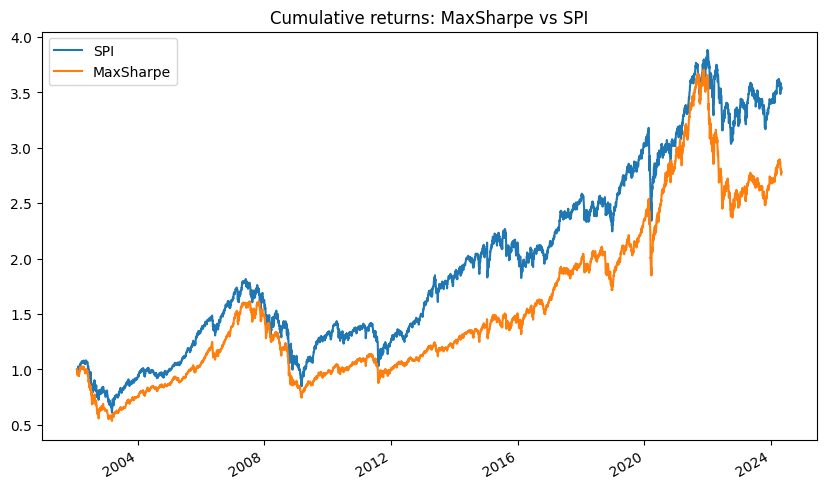

In [32]:
fixed_costs = 0.01
variable_costs = 0.003
return_series = bs.data.get_return_series(weekdays_only=False)

sim_ms = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim = pd.concat({
    'SPI': bs.data.bm_series,
    'MaxSharpe': sim_ms,
}, axis=1).dropna()

cumret = (1 + sim).cumprod()
cumret.plot(figsize=(10, 6), title='Cumulative returns: MaxSharpe vs SPI')

<Axes: title={'center': 'Turnover'}>

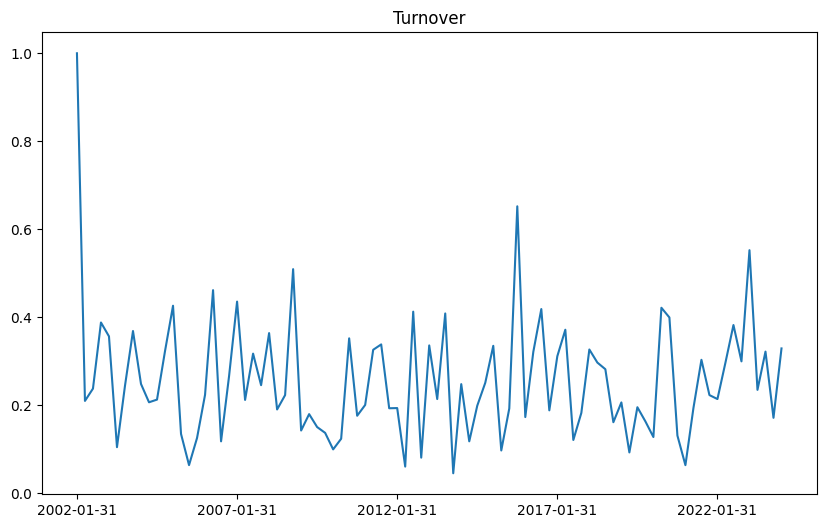

In [33]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_ms.plot(title='Turnover', figsize = (10, 6))

In [34]:
# Annualized turnover per annum (pa) in percentage
to_pa = to_ms.iloc[1:].mean() * (12 / n_month) * 100
print(f"The annualized turnover is: {to_pa:.2f}%")

The annualized turnover is: 99.97%


In [37]:
# Descriptive statistics

r_ms = sim['MaxSharpe'].dropna()
wealth_ms = (1 + r_ms).cumprod()
drawdown_ms = wealth_ms / wealth_ms.cummax() - 1
ann_return_ms = (1 + r_ms).prod() ** (252 / len(r_ms)) - 1
ann_vol_ms = r_ms.std() * np.sqrt(252)
sharpe_ms = ann_return_ms / ann_vol_ms
max_dd_ms = drawdown_ms.min()
total_return_ms = wealth_ms.iloc[-1] - 1

r_bm = sim['SPI'].dropna()
wealth_bm = (1 + r_bm).cumprod()
drawdown_bm = wealth_bm / wealth_bm.cummax() - 1
ann_return_bm = (1 + r_bm).prod() ** (252 / len(r_bm)) - 1
ann_vol_bm = r_bm.std() * np.sqrt(252)
sharpe_bm = ann_return_bm / ann_vol_bm
max_dd_bm = drawdown_bm.min()
total_return_bm = wealth_bm.iloc[-1] - 1

stats = pd.DataFrame({
    'MaxSharpe': [
        total_return_ms,
        ann_return_ms,
        ann_vol_ms,
        sharpe_ms,
        max_dd_ms,
    ],
    'SPI': [
        total_return_bm,
        ann_return_bm,
        ann_vol_bm,
        sharpe_bm,
        max_dd_bm,
    ]
}, index=[
    'Total return',
    'Annualized return',
    'Annualized volatility',
    'Sharpe ratio',
    'Max drawdown',
])

display(stats.round(4))

,MaxSharpe,SPI
Total return,1.7777,2.5325
Annualized return,0.0448,0.0556
Annualized volatility,0.1446,0.1647
Sharpe ratio,0.3099,0.3379
Max drawdown,-0.5370,-0.5325


In [40]:
pd.concat([
    sim['MaxSharpe'].describe().rename('MaxSharpe'),
    sim['SPI'].describe().rename('SPI')
], axis=1)

,MaxSharpe,SPI
count,5873.000000,5873.000000
mean,0.000216,0.000269
std,0.009109,0.010372
min,-0.080454,-0.091109
25%,-0.003630,-0.004282
50%,0.000339,0.000262
75%,0.004871,0.005273
max,0.079111,0.105788
